In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/TBD/salary_dataset.csv"

df = pd.read_csv(url)

df.head()

,Experience Years,Salary
0,0.6,27868
1,0.6,31381
2,0.7,44204
3,0.8,39551
4,0.9,25984


In [3]:
# Number of rows and columns
print("Shape of dataset:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns)

# Information about the dataset
print("\nDataset information:")
df.info()

# Statistical summary
print("\nStatistical summary:")
print(df.describe())

Shape of dataset: (200, 2)

Column names:
Index(['Experience Years', 'Salary'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  200 non-null    float64
 1   Salary            200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB

Statistical summary:
       Experience Years         Salary
count        200.000000     200.000000
mean           7.519000   96834.455000
std            4.279792   40938.012116
min            0.600000   25984.000000
25%            3.800000   60248.500000
50%            7.700000   94732.000000
75%           11.500000  132854.500000
max           14.800000  173265.000000


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Experience Years    0
Salary              0
dtype: int64


In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (200, 2)


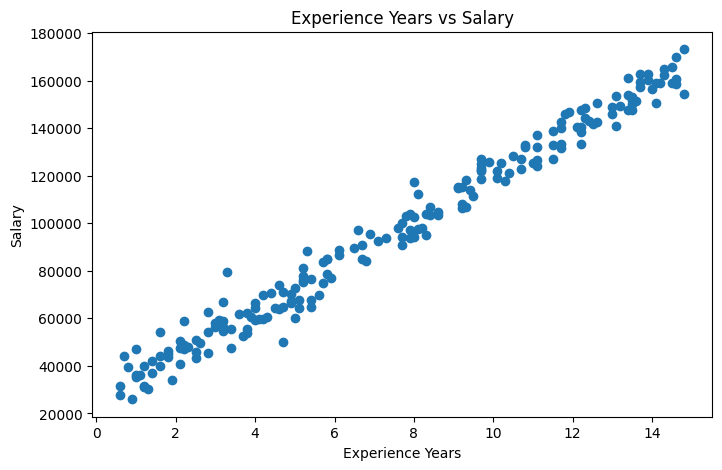

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Experience Years"], df["Salary"])

plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience Years vs Salary")

plt.show()

In [8]:
X = df[["Experience Years"]]
y = df["Salary"]

print("Feature (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Feature (X):
   Experience Years
0               0.6
1               0.6
2               0.7
3               0.8
4               0.9

Target (y):
0    27868
1    31381
2    44204
3    39551
4    25984
Name: Salary, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 1)
Testing data: (40, 1)


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [14]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 25755.14781172425
Coefficient: 9437.993959443527


In [15]:
print(
    f"Salary = {model.intercept_:.2f} + "
    f"({model.coef_[0]:.2f} × Experience Years)"
)

Salary = 25755.15 + (9437.99 × Experience Years)


In [16]:
y_pred = model.predict(X_test)

print("Predicted salaries:")
print(y_pred[:10])

Predicted salaries:
[ 90877.30613188  40855.93814683  49350.13271033 139954.87472099
 117303.68921833 105034.29707105  72945.11760894 148449.06928449
 152224.26686827  57844.32727383]


In [17]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

print(comparison.head(10))

   Actual Salary  Predicted Salary
0          95688      90877.306132
1          39842      40855.938147
2          43366      49350.132710
3         140441     139954.874721
4         122264     117303.689218
5         106946     105034.297071
6          72849      72945.117609
7         146188     148449.069284
8         160947     152224.266868
9          55712      57844.327274


In [18]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 4056.343861389738


In [19]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 23745684.254818656


In [20]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 4872.954366174452


In [21]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9831368268457784


In [22]:
print("MODEL EVALUATION")
print("-------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MODEL EVALUATION
-------------------------
MAE  : 4056.34
MSE  : 23745684.25
RMSE : 4872.95
R²   : 0.9831


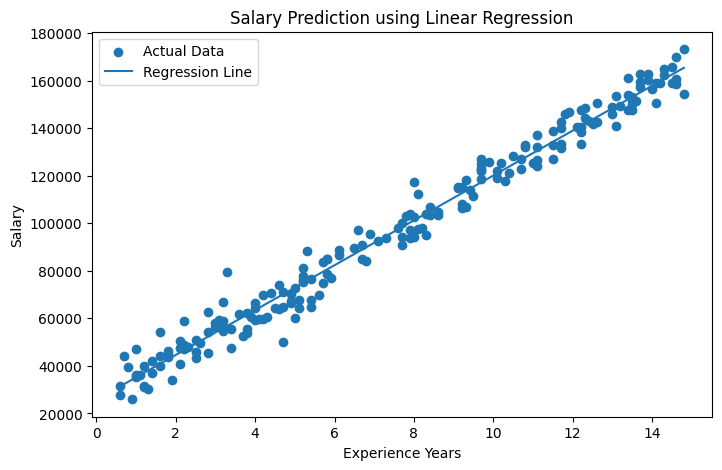

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")

plt.legend()
plt.show()

In [24]:
import joblib

joblib.dump(model, "salary_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
